# Import des bibliothèques nécessaires

In [1]:
import mysql.connector

from mysql.connector import Error
import pandas as pd
import matplotlib.pyplot as plt

# Fonction permettant de se connecter à la base de données

In [2]:
def getBDD():
    try:
        bdd = mysql.connector.connect(
            host='localhost',
            database='gamesale',
            user='root',
            password='',
            charset='utf8'
        )
        return bdd
    except Error as e:
        print("Erreur connexion: " + str(e))
        return None


# Fonction pour analyse de variable qualitative nominale

In [3]:
def analyse_uni_quali_nom2(table_principale, table_liaison,nom_colonne,nom_id):

    bdd = getBDD()
    if not bdd:
        return None
    
    try:
        query = """
        SELECT 
            p."""+nom_colonne+""" as """+nom_colonne+""", 
            COUNT(l.id_jeu) as Nb_Jeux
        FROM """ + table_principale + """ p
        LEFT JOIN """ + table_liaison + """ l ON p."""+nom_id+""" = l."""+nom_id+"""
        GROUP BY p."""+nom_id+""", p."""+nom_colonne+"""
        ORDER BY Nb_Jeux DESC
        """
        
        df=pd.read_sql_query(query,bdd)
        bdd.close()
        
        # Analyse
        print("Analyse univariée : Jeux par " +nom_colonne)
        print(df)
        print("Nombre total de "+nom_colonne+" : " + str(len(df)))
        print("Nombre total de jeux : " + str(df['Nb_Jeux'].sum()))
        
        # Graphique
        plt.figure(figsize=(12, 6))
        bars = plt.bar(range(len(df)), df['Nb_Jeux'],width=0.2, color='skyblue', edgecolor='navy')
        plt.title('Nombre de jeux par '+nom_colonne)
        plt.xlabel(nom_colonne)
        plt.ylabel('Nombre de jeux')
        plt.xticks(range(len(df)), df[nom_colonne], rotation=45, ha='right')
        
        # Nombres sur les barres
        for i, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    str(int(height)), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        return df
        
    except Error as e:
        print("Erreur : " + str(e))
        return None

def analyse_uni_quali_nom(nom_table):
    
    bdd = getBDD()
    if not bdd:
        return None
    
    try:
        query = """ SELECT """+nom_table+""", COUNT(id_jeu) as Nb_Jeux FROM """+nom_table+""" GROUP BY """ + nom_table + """
        ORDER BY Nb_Jeux DESC
        LIMIT 20
        """
        
        df=pd.read_sql_query(query,bdd)
        bdd.close()
        
        # Analyse
        print("Analyse univariée : Jeux par " +nom_table)
        print(df)
        print("Nombre total de "+nom_table+" : " + str(len(df)))
        print("Nombre total de jeux : " + str(df['Nb_Jeux'].sum()))
        
        # Graphique
        plt.figure(figsize=(12, 6))
        bars = plt.bar(range(len(df)), df['Nb_Jeux'],width=0.3, color='skyblue', edgecolor='navy')
        plt.title('Nombre de jeux par '+nom_table)
        plt.xlabel(nom_table)
        plt.ylabel('Nombre de jeux')
        plt.xticks(range(len(df)), df[nom_table], rotation=45, ha='right')
        
        # Nombres sur les barres
        for i, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    str(int(height)), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        return df
        
    except Error as e:
        print("Erreur : " + str(e))
        return None



# Utilisation des fonctions ci dessus pour analyse de différentes variables qualitatives nominales.

C:\Users\Catherine\AppData\Local\Temp\ipykernel_19764\29739889.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,bdd)


Analyse univariée : Jeux par categorie
                     categorie  Nb_Jeux
0                Single-player      765
1           Steam Achievements      369
2                  Steam Cloud      329
3                 Multi-player      275
4          Steam Trading Cards      269
5      Full controller support      203
6   Partial Controller Support      196
7                        Co-op      119
8           Steam Leaderboards      116
9          Shared/Split Screen       81
10              Steam Workshop       36
11       Includes level editor       33
12                       Stats       30
13         Online Multi-Player       28
14  Cross-Platform Multiplayer       26
15          Local Multi-Player       24
16          Captions available       19
17    Valve Anti-Cheat enabled       18
18                 Local Co-op        9
19        Commentary available        5
20         Includes Source SDK        4
Nombre total de categorie : 21
Nombre total de jeux : 2954


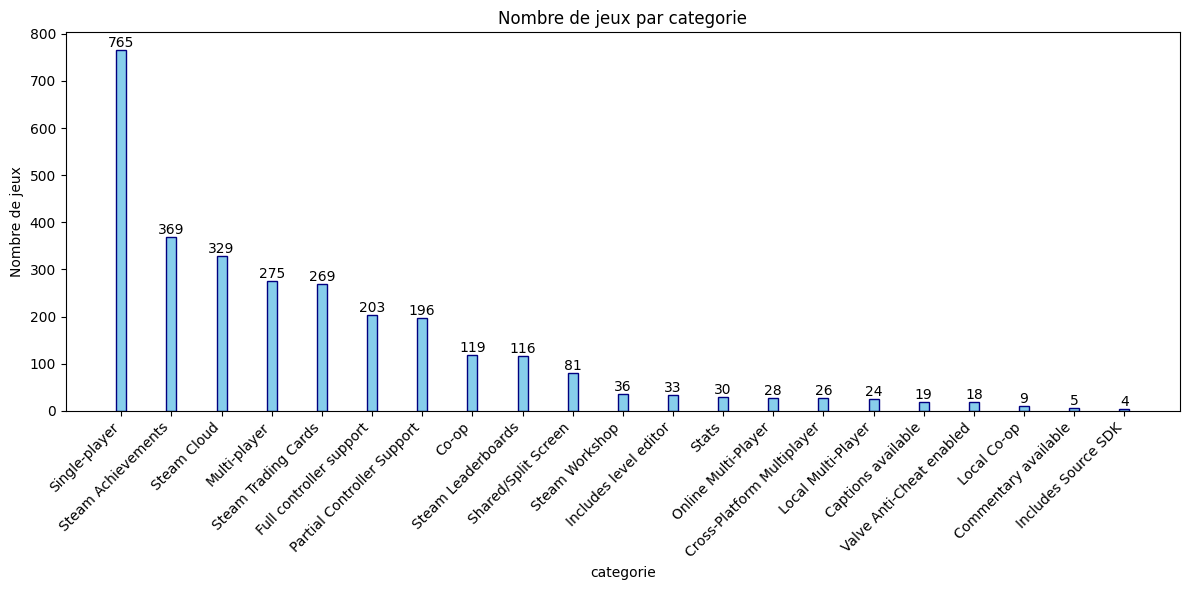

Analyse univariée : Jeux par OS
        OS  Nb_Jeux
0  windows      780
1      mac      164
2    linux      106
Nombre total de OS : 3
Nombre total de jeux : 1050


C:\Users\Catherine\AppData\Local\Temp\ipykernel_19764\29739889.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,bdd)


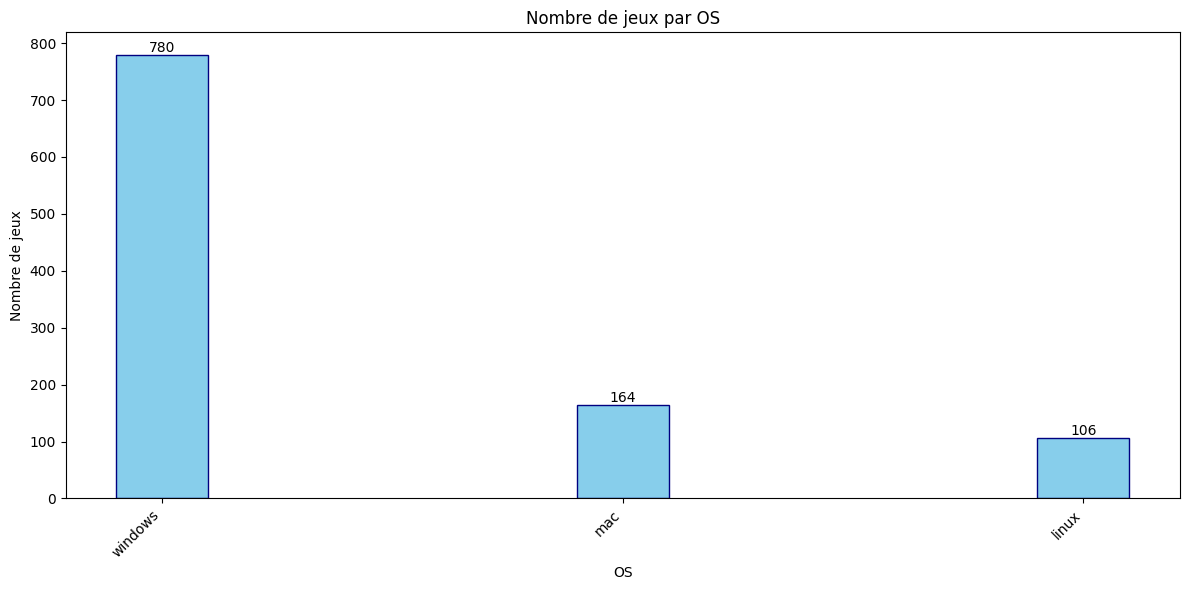

Analyse univariée : Jeux par developpeur
                   developpeur  Nb_Jeux
0             Ubisoft Montreal       13
1                  Square Enix       12
2   KOEI TECMO GAMES CO., LTD.       11
3             Arc System Works        9
4                  id Software        8
5            Traveller's Tales        8
6                 Nihon Falcom        7
7                    LucasArts        7
8                       Capcom        7
9                        Valve        7
10                     Ubisoft        7
11                   Rebellion        7
12          Team17 Digital Ltd        6
13            Crystal Dynamics        6
14                        SEGA        6
15            Gearbox Software        5
16              EA Los Angeles        5
17                     BioWare        5
18                  MumboJumbo        5
19           Gas Powered Games        5
Nombre total de developpeur : 20
Nombre total de jeux : 146


C:\Users\Catherine\AppData\Local\Temp\ipykernel_19764\29739889.py:62: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,bdd)


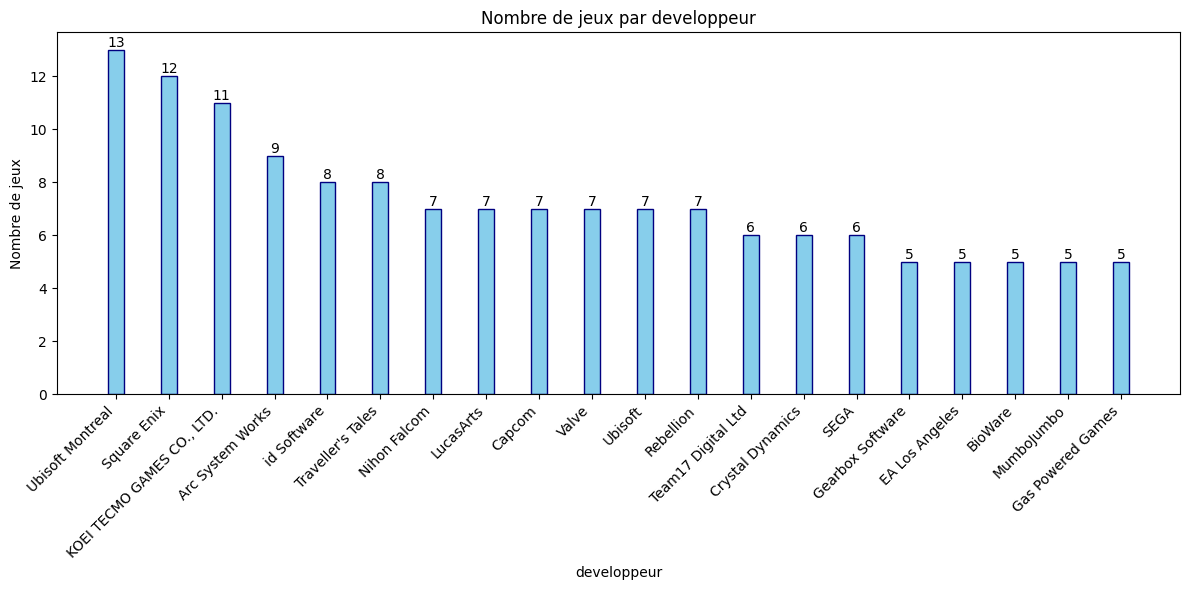

C:\Users\Catherine\AppData\Local\Temp\ipykernel_19764\29739889.py:62: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,bdd)


Analyse univariée : Jeux par genre
           genre  Nb_Jeux
0         Action      174
1        Shooter      147
2       Strategy      101
3   Role-Playing       88
4      Adventure       66
5         Racing       42
6     Simulation       40
7       Platform       34
8         Puzzle       33
9       Fighting       24
10        Sports       17
11          Misc       14
Nombre total de genre : 12
Nombre total de jeux : 780


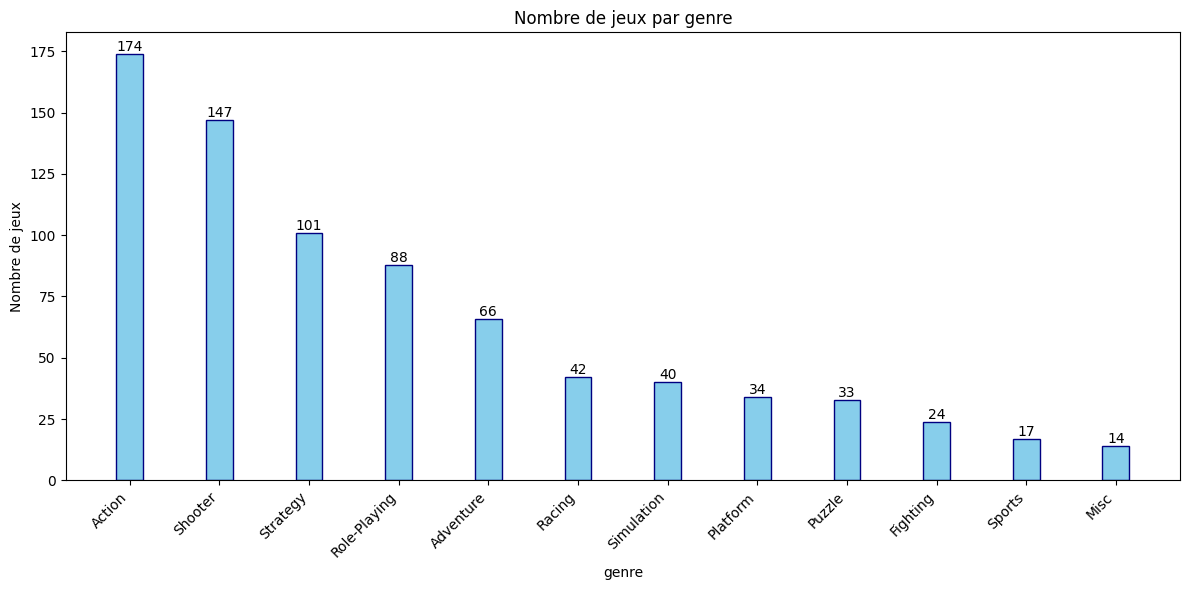

C:\Users\Catherine\AppData\Local\Temp\ipykernel_19764\29739889.py:62: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,bdd)


Analyse univariée : Jeux par editeur
                                   editeur  Nb_Jeux
0                                  Ubisoft       49
1                              Square Enix       39
2                               THQ Nordic       26
3                          Electronic Arts       24
4                                     SEGA       22
5                                   Capcom       16
6                              Deep Silver       16
7                       Bethesda Softworks       15
8               BANDAI NAMCO Entertainment       15
9                    Kalypso Media Digital       14
10                          Rockstar Games       13
11                                      2K       13
12  Warner Bros. Interactive Entertainment       12
13                     Paradox Interactive       12
14              KOEI TECMO GAMES CO., LTD.       11
15                              Activision       10
16                             Codemasters       10
17                      Dis

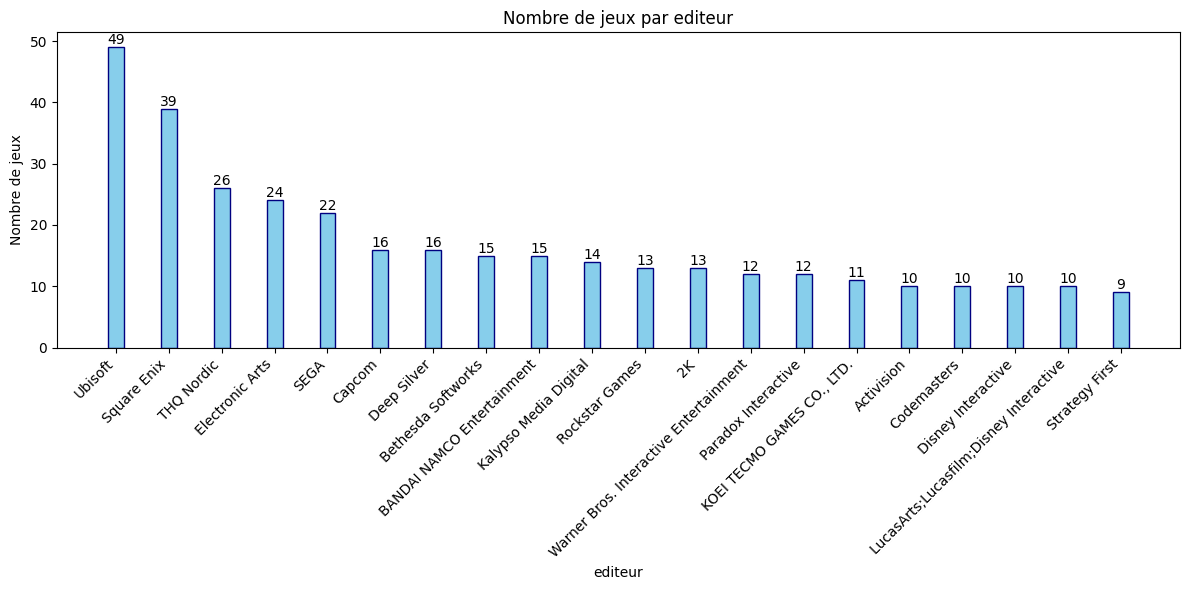

,editeur,Nb_Jeux
0,Ubisoft,49
1,Square Enix,39
2,THQ Nordic,26
3,Electronic Arts,24
4,SEGA,22
5,Capcom,16
6,Deep Silver,16
7,Bethesda Softworks,15
8,BANDAI NAMCO Entertainment,15
9,Kalypso Media Digital,14


In [4]:
analyse_uni_quali_nom2("categorie","a_categorie","categorie","id_cat")
analyse_uni_quali_nom2("os","a_os","OS","id_os")

analyse_uni_quali_nom("developpeur")
analyse_uni_quali_nom("genre")
analyse_uni_quali_nom("editeur")

# Fonction pour analyse de variable qualitative ordinale

In [6]:
def analyse_uni_quali_ord(nom_table,nom_colonne):
    
    bdd = getBDD()
    if not bdd:
        return None
    
    try:
        query = """ SELECT """+nom_colonne+""", COUNT(id_jeu) as Nb_Jeux FROM """+nom_table+""" GROUP BY """+nom_colonne+"""
        ORDER BY """+nom_colonne+""" ASC
        LIMIT 20
        """
        
        df=pd.read_sql_query(query,bdd)
        bdd.close()
    

        # Analyse
        print("Analyse univariée : Jeux par " +nom_colonne)
        print(df)
        print(nom_colonne + str(len(df)))
        print("Nombre total de jeux : " + str(df['Nb_Jeux'].sum()))
        
        # Graphique
        plt.figure(figsize=(12, 6))
        bars = plt.bar(range(len(df)), df['Nb_Jeux'], width=1 ,color='skyblue', edgecolor='navy')
        plt.title('Nombre de jeux par '+nom_colonne)
        plt.xlabel(nom_colonne)
        plt.ylabel('Nombre de jeux')
        plt.xticks(range(len(df)), df[nom_colonne], rotation=45, ha='right')
        
        # Nombres sur les barres
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    str(int(height)), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        return df
        
    except Error as e:
        print("Erreur : " + str(e))
        return None

# Utilisation de la fonction ci-dessus pour analyser des fonctions qualitatives ordinales

Analyse univariée : Jeux par age_requis
   age_requis  Nb_Jeux
0           0      665
1           7        2
2          12       11
3          16       40
4          18       62
age_requis5
Nombre total de jeux : 780


C:\Users\Catherine\AppData\Local\Temp\ipykernel_19764\1617278652.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,bdd)


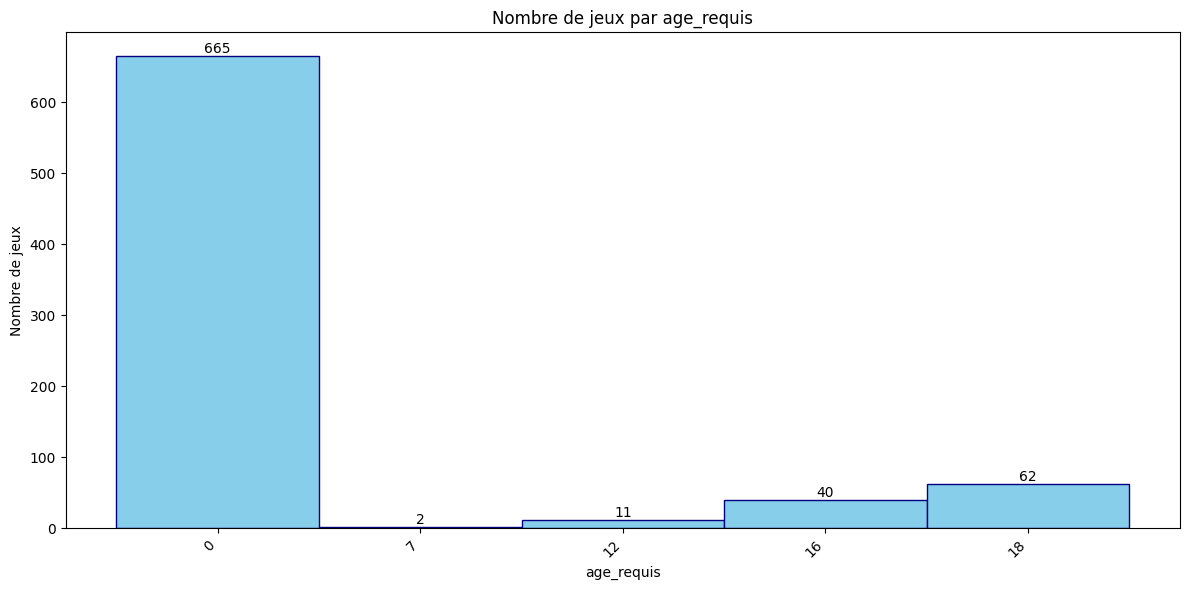

C:\Users\Catherine\AppData\Local\Temp\ipykernel_19764\1617278652.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query(query,bdd)


Analyse univariée : Jeux par annee
   annee  Nb_Jeux
0              23
1   1998        1
2   2000        1
3   2002        1
4   2004        2
5   2005        1
6   2006       10
7   2007       31
8   2008       57
9   2009       93
10  2010       60
11  2011       68
12  2012       52
13  2013       45
14  2014       93
15  2015       80
16  2016       77
17  2017       45
18  2018       34
19  2019        6
annee20
Nombre total de jeux : 780


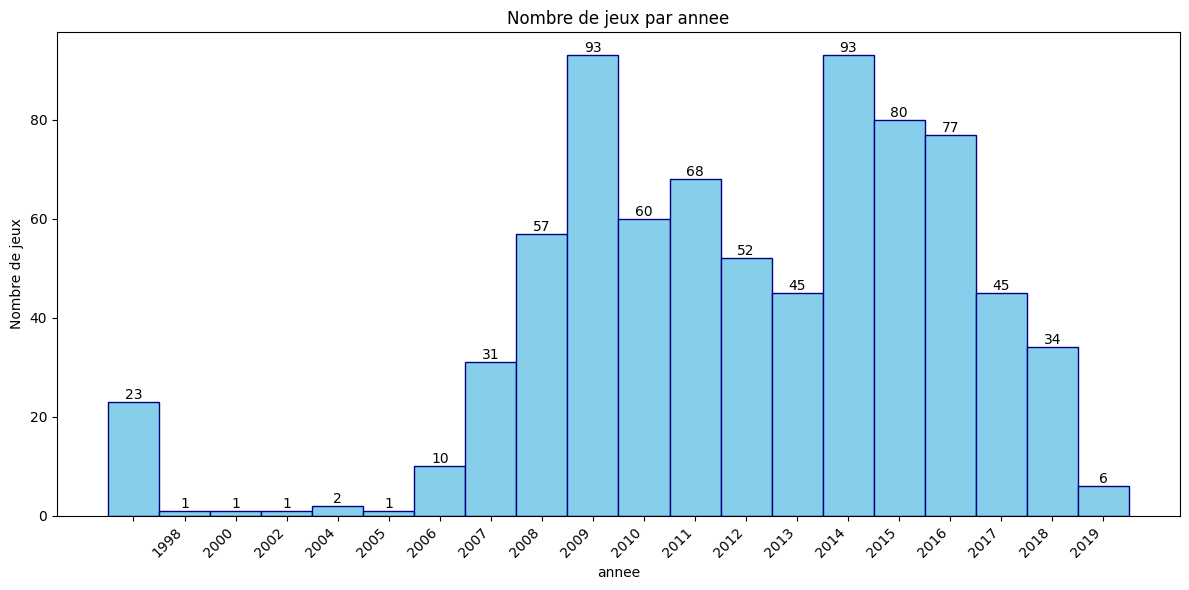

,annee,Nb_Jeux
0,,23
1,1998,1
2,2000,1
3,2002,1
4,2004,2
5,2005,1
6,2006,10
7,2007,31
8,2008,57
9,2009,93


In [7]:
analyse_uni_quali_ord('jeux','age_requis')
analyse_uni_quali_ord('jeux','annee')